## Post-agent parameter evaluation for Muraro (no-biology)

**Agent-selected parameters:**
- `n_neighbors = 15`
- `resolution = 0.6`
- `n_pcs = 30`

### 1. Reference-based evaluation
The agent-derived clustering was compared with the published Muraro cell-type annotations using:
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)
- Cluster × reference-label contingency tables (row- and column-normalized)

Results:
- ARI = 0.5896
- NMI = 0.7825

### 2. Clustering stability
The selected configuration was repeated across multiple random seeds to assess robustness to stochastic variation:
- Cluster-count distribution
- Pairwise ARI
- Pairwise NMI

Results:
- Mean ARI = 0.8786
- Mean NMI = 0.9462
- Cluster counts: 14–15 across runs

### 3. Parameter sensitivity
The agent-selected configuration was compared with small perturbations of each optimization parameter:
- `n_neighbors`: 10 and 20
- `resolution`: 0.5 and 0.7
- `n_pcs`: 20 and 40

Each configuration was evaluated using:
- Number of clusters
- ARI relative to the agent configuration
- NMI relative to the agent configuration

### 4. Biological validation
Established pancreatic cell-type markers were examined post-hoc using the full-gene expression data while retaining the agent-derived cluster assignments. Expression was normalized and log-transformed for visualization only.

Marker patterns were broadly consistent with the published cell-type annotations, providing an additional biological plausibility check.

### 5. Limitation
The agent was run with a maximum budget of **6 iterations**. Therefore, the selected parameters represent the best configuration identified within the allowed search budget rather than an exhaustive search of the parameter space. The limited iteration budget may have restricted the agent's ability to explore alternative parameter combinations.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from dotenv import load_dotenv
import os

load_dotenv(override=True)


True

In [3]:
# Stability analysis
from pathlib import Path
from src.new_evaluation import calculate_silhouette_score
import importlib
from src import muraro_data as md
from src import muraro_preprocessing as mp
from src import clustering as cl
from src import stability as stability
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,)
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from collections import Counter

## 1. Data Load and Reference Annotation 

In [4]:
# Download Muraro expression data if needed
muraro_expression_file = md.download_muraro_expression()

# Create the AnnData file if it does not already exist
muraro_h5ad = Path("data/muraro/muraro_raw.h5ad")

if not muraro_h5ad.exists():
    md.create_muraro_h5ad(
        muraro_expression_file,
        output_file=muraro_h5ad
    )

# Load Muraro expression data
muraro = md.load_muraro_expression()

# Reference Annotations
muraro_annotations = md.load_muraro_annotations()

muraro = md.attach_reference_annotations(
    muraro,
    muraro_annotations
)

## 2. Preprocessing

In [5]:
# Preprocess first
muraro_processed = mp.run_preprocessing_pipeline(
    muraro.copy()
)
muraro_eval = md.get_evaluation_subset(
    muraro_processed)

Running Muraro QC...
Running normalization...
Running PCA...
Finished Muraro preprocessing.


In [6]:
print("Expression cells:", muraro.shape[1])
print("Annotation cells:", muraro_annotations.shape[0])
print(
    "All cell IDs match:",
    set(muraro.obs_names) == set(muraro_annotations["cell_id"])
)

Expression cells: 19140
Annotation cells: 3072
All cell IDs match: True


## 2. Seed Stability / Robustness Check

The stability analysis assesses whether the clustering result is **reproducible across different random seeds**. The same clustering configuration was therefore repeated across 20 random seeds, while keeping all clustering parameters fixed.

A clustering result is considered more robust when the resulting cluster assignments remain reasonably consistent across these repeated runs. This provides evidence that the observed structure is not primarily driven by stochastic variation in the clustering procedure.

Stability was assessed using:
- cluster-count consistency
- pairwise ARI
- pairwise NMI

In [7]:
muraro_full_data = muraro_processed.copy()

stability_results = stability.run_stability_analysis(
    muraro_full_data,
    n_neighbors=15,
    resolution=0.6,
    n_pcs=30,
    seeds=[0, 1, 2, 3, 4, 5, 10, 20, 42, 100],)

print("Cluster counts:", stability_results["cluster_counts"])

Cluster counts: [15, 14, 14, 14, 15, 14, 14, 14, 15, 14]


Although the number of detected clusters varied slightly between 14 and 15 across seeds, the high similarity between partitions indicates that the overall clustering structure was largely preserved.

In [8]:
print(type(stability_results))
print(stability_results.keys())
print(len(stability_results["assignments"]))

<class 'dict'>
dict_keys(['assignments', 'cluster_counts'])
10


In [9]:
cluster_count_frequency = Counter(stability_results["cluster_counts"])

print("Cluster count frequency:")
for k, count in sorted(cluster_count_frequency.items()):
    print(f"K={k}: {count}/10 runs")

Cluster count frequency:
K=14: 7/10 runs
K=15: 3/10 runs


#### 2b Seed Stability Analysis check with ARI and NMI

How stable/reproducible is the clustering when the same parameters are rerun?

##### calculate_pairwise_ari
+ Compares every clustering run with every other run.
+ Checks how consistently the cells are grouped across runs.

##### calculate_pairwise_nmi
+ Also compares every run with every other run.
+ Checks how much information about the clustering is shared across runs.

In [10]:
ari_scores = stability.calculate_pairwise_ari(
    stability_results["assignments"]
)

nmi_scores = stability.calculate_pairwise_nmi(
    stability_results["assignments"]
)

print("Number of pairwise comparisons:", len(ari_scores))

print("-----------------")
print("Stability summary")
print("-----------------")

print(f"Mean ARI:   {np.mean(ari_scores):.4f}")
print(f"Median ARI: {np.median(ari_scores):.4f}")
print(f"SD ARI:     {np.std(ari_scores):.4f}")
print(f"Min ARI:    {np.min(ari_scores):.4f}")
print(f"Max ARI:    {np.max(ari_scores):.4f}")

print()

print(f"Mean NMI:   {np.mean(nmi_scores):.4f}")
print(f"Median NMI: {np.median(nmi_scores):.4f}")
print(f"SD NMI:     {np.std(nmi_scores):.4f}")
print(f"Min NMI:    {np.min(nmi_scores):.4f}")
print(f"Max NMI:    {np.max(nmi_scores):.4f}")

Number of pairwise comparisons: 45
-----------------
Stability summary
-----------------
Mean ARI:   0.8786
Median ARI: 0.8576
SD ARI:     0.0641
Min ARI:    0.7854
Max ARI:    0.9945

Mean NMI:   0.9462
Median NMI: 0.9448
SD NMI:     0.0254
Min NMI:    0.8980
Max NMI:    0.9944



The **NMI: 0.946 mean** with a minimum of 0.898 suggests the repeated partitions are highly similar in their overall information structure.

The ARI is also strong, although its larger variability tells us that some individual cluster assignments change somewhat between seeds.

### 3. Parameter Sensitivity Analysis

The agent-selected configuration is used as the baseline. Each sensitivity configuration varies one optimization parameter while keeping the remaining parameters fixed. The tested configurations are defined explicitly to make the analysis reproducible and easy to update if the agent-selected parameters change.
##### `calculate_ari_vs_reference`

- Compares each parameter configuration against **one reference clustering**, defined as the agent-selected configuration.
- Measures how similar the resulting cluster assignments remain when individual parameters are changed.

##### `calculate_nmi_vs_reference`

- Uses the same setup, comparing each parameter configuration with the agent-selected reference clustering.
- Measures how much information about the cluster structure is preserved when individual parameters are changed.

In [11]:
# Parameter configurations for post-agent sensitivity analysis.
# The agent-selected configuration is used as the baseline.
# Each sensitivity configuration changes one parameter while
# keeping the remaining parameters fixed.

parameter_configs = {
    "agent": (15, 0.6, 30),

    "neighbors_low": (10, 0.6, 30),
    "neighbors_high": (20, 0.6, 30),

    "resolution_low": (15, 0.5, 30),
    "resolution_high": (15, 0.7, 30),

    "pcs_low": (15, 0.6, 20),
    "pcs_high": (15, 0.6, 40),
}

In [12]:
sensitivity_assignments = []
sensitivity_metadata = []

for name, (n_neighbors, resolution, n_pcs) in parameter_configs.items():

    adata_full = muraro_processed.copy()

    adata_full = cl.run_clustering(
        adata_full,
        n_neighbors=n_neighbors,
        resolution=resolution,
        n_pcs=n_pcs,
        random_state=42,
    )

    labels = adata_full.obs["leiden"].to_numpy()

    sensitivity_assignments.append(labels)

    sensitivity_metadata.append({
        "configuration": name,
        "n_neighbors": n_neighbors,
        "resolution": resolution,
        "n_pcs": n_pcs,
        "n_clusters": len(np.unique(labels)),
    })

In [13]:
print(len(sensitivity_assignments))
print([len(x) for x in sensitivity_assignments])

7
[2680, 2680, 2680, 2680, 2680, 2680, 2680]


In [14]:
ari_scores = stability.calculate_ari_vs_reference(
    sensitivity_assignments,
    reference_index=0 # reference 0 because the dictionary starts with the agent parameter/clustering
)

nmi_scores = stability.calculate_nmi_vs_reference(
    sensitivity_assignments,
    reference_index=0
)

In [15]:
for i in range(len(sensitivity_metadata)):

    sensitivity_metadata[i]["ARI_vs_agent"] = ari_scores[i]
    sensitivity_metadata[i]["NMI_vs_agent"] = nmi_scores[i]

In [16]:
sensitivity_df = pd.DataFrame(sensitivity_metadata)

print(sensitivity_df)

     configuration  n_neighbors  resolution  n_pcs  n_clusters  ARI_vs_agent  \
0            agent           15         0.6     30          15      1.000000   
1    neighbors_low           10         0.6     30          15      0.952550   
2   neighbors_high           20         0.6     30          14      0.840553   
3   resolution_low           15         0.5     30          14      0.863527   
4  resolution_high           15         0.7     30          15      0.978658   
5          pcs_low           15         0.6     20          15      0.905676   
6         pcs_high           15         0.6     40          14      0.815134   

   NMI_vs_agent  
0      1.000000  
1      0.966941  
2      0.939000  
3      0.957715  
4      0.984935  
5      0.934230  
6      0.920875  


Local parameter sensitivity analysis showed that the agent-selected configuration was robust to moderate perturbations of the optimization parameters. All perturbed configurations showed high agreement with the agent-selected partition (ARI = 0.815–0.979; NMI = 0.921–0.985). The largest changes occurred for higher numbers of principal components and higher neighborhood size, which also resulted in a reduction from 15 to 14 clusters. In contrast, increasing the resolution from 0.6 to 0.7 produced a nearly identical partition (ARI = 0.979; NMI = 0.985).

# 4. Muraro Reference-Label Validation: Full Data vs Evaluation Subset

This analysis evaluates how well the agent-selected clustering agrees with the
external Muraro reference labels. The reference labels were **not available
to the agent during optimization** and are used only for post-hoc validation.

- The selected parameters were:
  - `n_neighbors = 15`
  - `resolution = 0.6`
  - `n_pcs = 30`

Two evaluation approaches are compared:
1. **Full-data clustering:** clustering performed on all cells available to the
   agent, followed by evaluation using the valid reference-labelled cells.
2. **Evaluation-subset clustering:** clustering performed directly on the
   2,122 cells with valid reference labels.

ARI and NMI are used to quantify agreement between the resulting Leiden
clusters and the external reference annotations.

### 4a. Using Evaluation-subset clustering

Clustering, ARI (using adjusted_rand_score), and NMI (normalized_mutual_info_score) was performed directly on the **2,122** valid reference-labelled cells:

In [17]:
muraro_2122_cell = muraro_eval.copy()

In [18]:
muraro_2122_cell = cl.run_clustering(
    muraro_2122_cell,
    n_neighbors=15,
    resolution=0.6,
    n_pcs=30,
    random_state=42,)

In [19]:
print(muraro_2122_cell.obs["cell_type_reference"].value_counts())

cell_type_reference
alpha          812
beta           448
duct           245
acinar         219
delta          193
pp             101
mesenchymal     80
endothelial     21
epsilon          3
Name: count, dtype: int64


In [20]:
reference_labels = muraro_2122_cell.obs["cell_type_reference"]
cluster_labels = muraro_2122_cell.obs["leiden"]

ari_eval = adjusted_rand_score(
    muraro_2122_cell.obs["cell_type_reference"],
    muraro_2122_cell.obs["leiden"])

nmi_eval = normalized_mutual_info_score(
    muraro_2122_cell.obs["cell_type_reference"],
    muraro_2122_cell.obs["leiden"])

print("Evaluation subset")
print("ARI:", ari_eval)
print("NMI:", nmi_eval)

Evaluation subset
ARI: 0.5126481915770252
NMI: 0.761102907925252


This answers: Among the 2122 cells for which we have a trustworthy reference label, how well does the clustering agree with that reference?

### 4b. Using Full-data
Same experiment was performed on the **2,680 cells** used by the agent and subsequently evaluated against the **2,122 cells with valid reference annotations**:

In [21]:
muraro_full_2680 = muraro_processed.copy()

muraro_full_2680 = cl.run_clustering(
    muraro_full_2680,
    n_neighbors=15,
    resolution=0.6,
    n_pcs=30,
    random_state=42,
)

In [22]:
print("Total cells:", muraro_full_2680.n_obs)

Total cells: 2680


In [23]:
print(muraro_full_2680.obs["leiden"].value_counts().sort_index())

leiden
0     433
1     231
2      22
3     195
4     430
5     258
6     281
7     111
8     201
9       6
10    281
11     58
12     10
13    143
14     20
Name: count, dtype: int64


In [24]:
valid_mask = (
    muraro_full_2680.obs["cell_type_reference"].notna()
    & (muraro_full_2680.obs["cell_type_reference"] != "unclear"))

reference = muraro_full_2680.obs.loc[
    valid_mask,
    "cell_type_reference"]

clusters_full = muraro_full_2680.obs.loc[
    valid_mask,
    "leiden"]

ari_full_on_valid = adjusted_rand_score(
    reference,
    clusters_full)

nmi_full_on_valid = normalized_mutual_info_score(
    reference,
    clusters_full)

print("Full-data clustering evaluated on valid reference cells")
print("ARI:", ari_full_on_valid)
print("NMI:", nmi_full_on_valid)

Full-data clustering evaluated on valid reference cells
ARI: 0.5895824971544327
NMI: 0.7825434918556297


The lower agreement (ARI & NMI from evaluation subset data compared with full-data clustering suggests that restricting the analysis to reference-labelled cells can alter the neighbourhood graph and, consequently, the resulting Leiden clustering.

Therefore, full-data clustering followed by post-hoc evaluation on valid reference-labelled cells is used as the **primary reference-label validation**. Clustering restricted to the evaluation subset is retained as a sensitivity analysis to assess the influence of the analysis population on reference agreement.

## 5.  Descriptive Cluster–Reference Label Analysis

Normalized contingency tables were used to characterize the correspondence between the **inferred Leiden clusters** and the **reference cell-type annotations**.

The analysis uses the full-data clustering result (`muraro_full_2680`) and restricts the contingency-table calculations to the **2,122 cells with valid reference annotations**.

Both row- and column-normalized tables were examined to describe:
- the reference-label composition of each inferred cluster (row-normalized)
- the distribution of each reference cell type across inferred clusters (column-normalized)

Because the agent selected the parameters `(n_neighbors=15, resolution=0.6, n_pcs=30)` using the full processed dataset, these descriptive analyses are performed on the corresponding full-data clustering result.

In [25]:
contingency = pd.crosstab(
    clusters_full,
    reference)

# print(contingency)

#### 5a. Row-normalized Table: What is Each Cluster Made Of?

The count table shows the number of reference-labelled cells in each Leiden cluster, while the **row-normalized percentages** show the proportion of each reference cell type within an individual cluster.

This therefore describes the **composition of each inferred cluster**.

For example, in this parameter run:
- **Cluster 1** consists entirely of reference **alpha** cells.
- **Cluster 4** consists predominantly of reference **beta** cells (95.1%).

Row-normalized percentages are therefore useful for assessing the biological composition and purity of individual inferred clusters.

In [26]:
contingency_pct = contingency.div(
    contingency.sum(axis=1),
    axis=0) * 100

# print(contingency_pct.round(1))

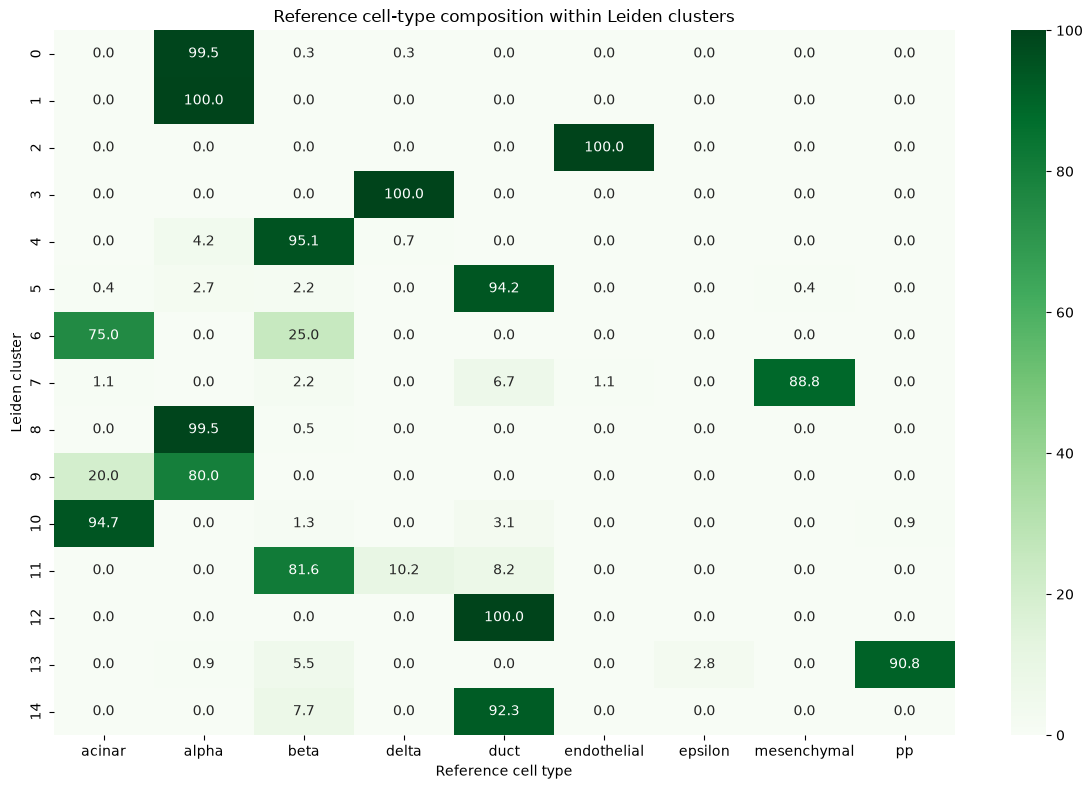

In [27]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    contingency_pct,
    annot=True,
    fmt=".1f",
    cmap="Greens"
)

plt.xlabel("Reference cell type")
plt.ylabel("Leiden cluster")
plt.title("Reference cell-type composition within Leiden clusters")

plt.tight_layout()
plt.show()

#### 5b. Column-normalized Table: Where Did Each Reference Population Go?

Unlike the row-normalized table, which describes the **composition of each inferred cluster**, the column-normalized table describes how each **reference cell population is distributed across the inferred Leiden clusters**.

This helps identify whether a reference population is:
- largely concentrated in a single cluster, or
- split across multiple clusters.

For example, in this parameter run, **86.6% of the reference beta cells are assigned to cluster 4**, indicating that most beta cells are concentrated in this cluster. Similarly, **95.3% of the reference delta cells are assigned to cluster 3**.

Column-normalized percentages therefore provide a descriptive way to assess the **distribution and potential splitting of reference cell populations across inferred clusters**.


In [28]:
reference_pct = contingency.div(
    contingency.sum(axis=0),
    axis=1
) * 100

# print(reference_pct.round(1))

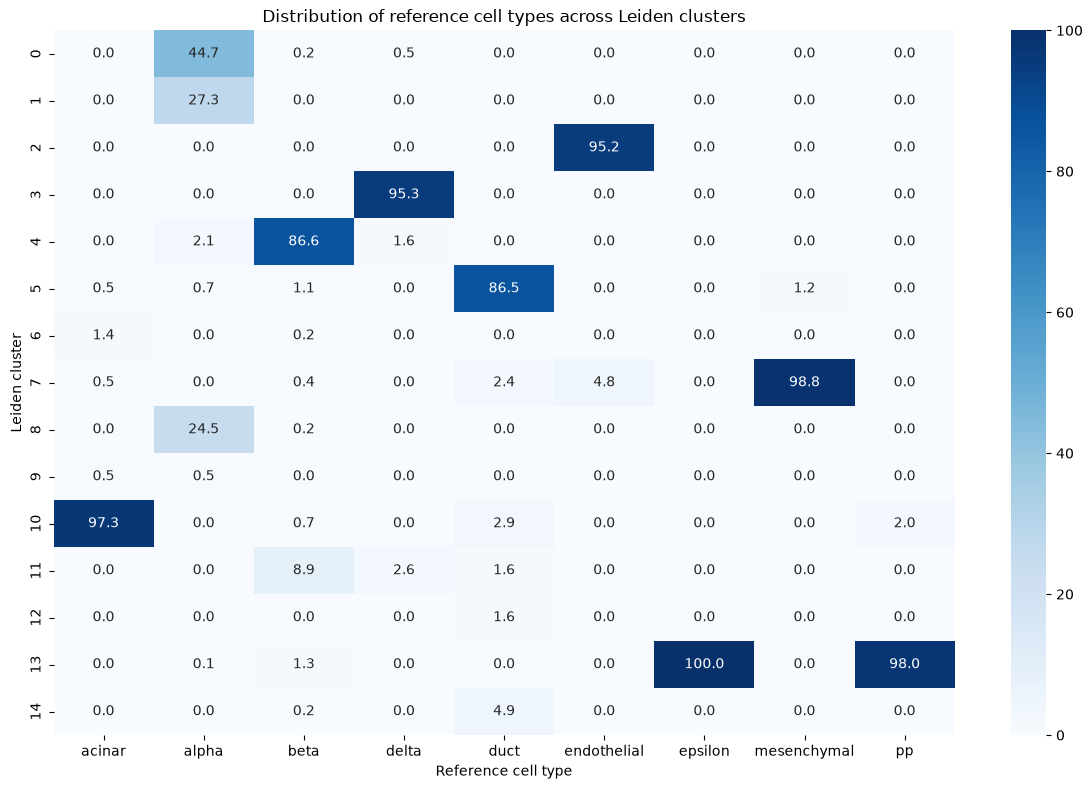

In [29]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    reference_pct,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.xlabel("Reference cell type")
plt.ylabel("Leiden cluster")
plt.title("Distribution of reference cell types across Leiden clusters")

plt.tight_layout()
plt.show()

Together, these contingency-table analyses provide **descriptive evidence of biological coherence and cluster–reference correspondence**, complementing the quantitative ARI and NMI results.

The moderate ARI (0.5896) can therefore be interpreted alongside these results: **splitting of some reference populations across multiple inferred clusters may have reduced global ARI while the individual clusters may still show strong correspondence with biologically coherent populations.**

## 6.  Biological Validation of Agent-selected Clustering

##### Selected Marker Genes

The biological plausibility of the agent-derived Leiden clusters was assessed using established cell-type markers reported for pancreatic cell populations. The resulting expression patterns were broadly consistent with the reference annotations, with GCG, INS, SST, PPY, PRSS1, KRT19, COL1A1, and ESAM showing enrichment in clusters corresponding to alpha, beta, delta, PP, acinar, ductal, mesenchymal, and endothelial populations, respectively. This provides an independent biological check of the clustering results in addition to quantitative agreement with the reference annotations.

Marker expression is examined across the existing Leiden clusters using a dot plot. **Expression data is then normalized and log-transformed for visualization only**; the clustering itself was not modified or repeated.

The marker-expression patterns are then assessed for consistency with the reference cell-type annotations and the contingency-table results.

In [30]:
muraro_marker_groups = {
    "Alpha": ["GCG__chr2"],
    "Beta": ["INS__chr11"],
    "Delta": ["SST__chr3"],
    "PP": ["PPY__chr17"],
    "Epsilon": ["GHRL__chr3"],
    "Acinar": ["PRSS1__chr7"],
    "Ductal": ["KRT19__chr17"],
    "Mesenchymal": ["COL1A1__chr17"],
    "Endothelial": ["ESAM__chr11"],
}

In [31]:
print(muraro.n_obs)
print(muraro_processed.n_obs)

print(muraro.obs_names[:5])
print(muraro_processed.obs_names[:5])

3072
2680
Index(['D28-1_1', 'D28-1_2', 'D28-1_3', 'D28-1_4', 'D28-1_5'], dtype='object')
Index(['D28-1_1', 'D28-1_2', 'D28-1_3', 'D28-1_4', 'D28-1_5'], dtype='object')


#### Transfer the existing agent cluster labels from the agent run

In [32]:
muraro_marker_validation = muraro[
    muraro_processed.obs_names
].copy()

muraro_marker_validation.obs["leiden"] = (
    muraro_full_2680.obs["leiden"]
    .reindex(muraro_marker_validation.obs_names)
)

sc.pp.normalize_total(
    muraro_marker_validation,
    target_sum=1e4
)

sc.pp.log1p(muraro_marker_validation)

In [33]:
print(muraro_marker_validation.obs["leiden"].value_counts().sort_index())

leiden
0     433
1     231
2      22
3     195
4     430
5     258
6     281
7     111
8     201
9       6
10    281
11     58
12     10
13    143
14     20
Name: count, dtype: int64


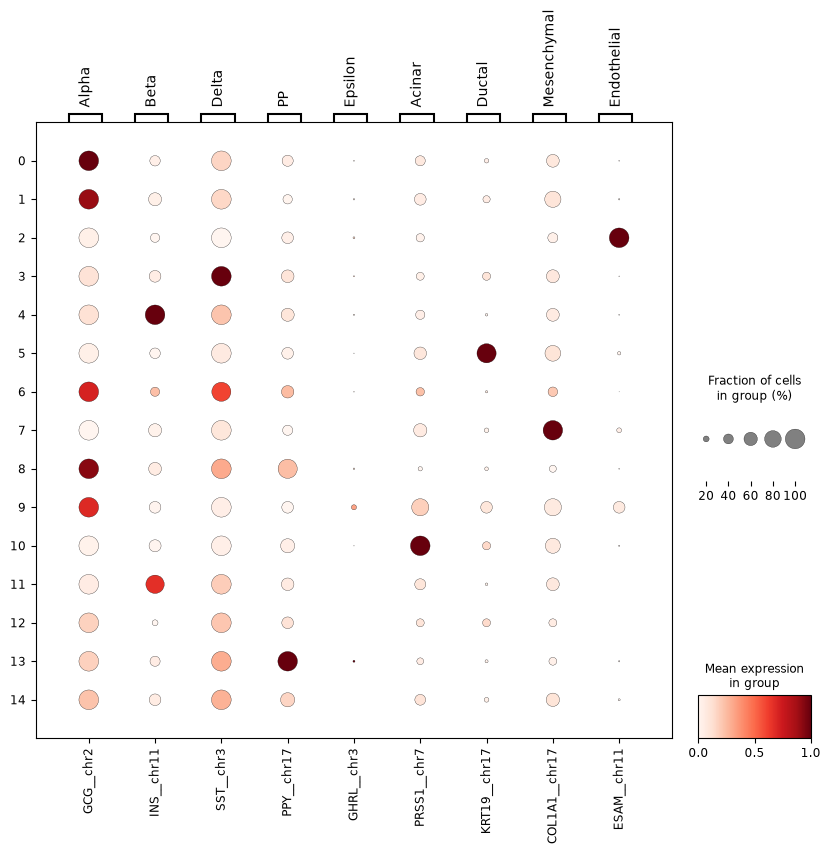

In [34]:
sc.pl.dotplot(
    muraro_marker_validation,
    var_names=muraro_marker_groups,
    groupby="leiden",
    standard_scale="var",
    figsize=(10, 8),
)